In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups

categories = [
    "sci.space",
    "rec.sport.baseball",
    "comp.graphics",
    "talk.politics.misc",
    "rec.autos"
]

news = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

df = pd.DataFrame({
    "text": news.data,
    "category": news.target
})

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (2833, 2)


,text,category
0,\n\n\n You are hereby authorized not to laugh...,4
1,\n: >Compiled from the last five Defensive Ave...,2
2,This notice will be posted weekly in sci.space...,3
3,"\nActually, there are people who will tell you...",3
4,,1


In [13]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2833, 2)

Columns:
Index(['text', 'category'], dtype='object')

Missing Values:
text        0
category    0
dtype: int64


In [14]:
df = df.dropna(subset=["text"])

df["text"] = df["text"].astype(str)

df = df[df["text"].str.strip() != ""]

df = df.drop_duplicates(subset=["text"])

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (2736, 2)


In [15]:
for i in range(3):
    print("\nArticle", i + 1)
    print(df["text"].iloc[i][:500])
    print("-" * 60)


Article 1



  You are hereby authorized not to laugh.  By special dispensation of
her Hillariness.  This offer void where prohibited by law, consumer must
pay applicable sales tax.....
-- 
-------------------------------------------------------------------------
------------------------------------------------------------

Article 2

: >Compiled from the last five Defensive Average reports, here are the career
: >DAs for the individual players in the reports.  Stats are courtesy of
: >Sherri Nichols.  Players are listed in descending order.

: And some comments, with some players deleted.

: >Third Basemen
: >-------------
: >Leius, Scott         ----  ----  ----  .653  .680   0.672
: Looks good.  Too bad he's moving to short.

: >Pagliarulo, Mike     .631  ----  .575  .744  ----   0.649
: This is an interesting line.  His 
------------------------------------------------------------

Article 3
This notice will be posted weekly in sci.space, sci.astro, and
sci.space.shuttle.

    The

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["text"])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (2736, 5000)


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    
    silhouette_scores.append(score)

print("Silhouette Scores:")
for k, score in zip(k_values, silhouette_scores):
    print("K =", k, "Score =", score)

Silhouette Scores:
K = 2 Score = 0.005767818856890139
K = 3 Score = 0.00517993935611131
K = 4 Score = 0.0058718148239489745
K = 5 Score = 0.006322045562601695
K = 6 Score = 0.006519533074397626
K = 7 Score = 0.006353426771336778
K = 8 Score = 0.006780991771817343


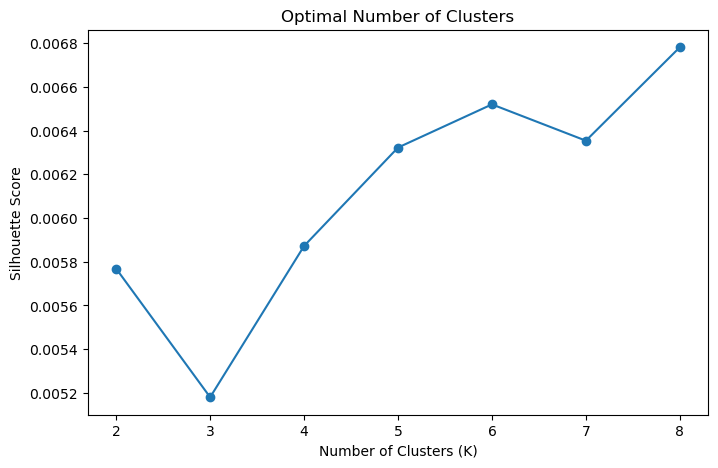

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Optimal Number of Clusters")

plt.show()

In [19]:
best_k = list(k_values)[np.argmax(silhouette_scores)]

best_score = max(silhouette_scores)

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", best_score)

Best Number of Clusters: 8
Best Silhouette Score: 0.006780991771817343


In [20]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X)

print("K-Means clustering completed!")

df.head()

K-Means clustering completed!


,text,category,KMeans_Cluster
0,\n\n\n You are hereby authorized not to laugh...,4,2
1,\n: >Compiled from the last five Defensive Ave...,2,7
2,This notice will be posted weekly in sci.space...,3,0
3,"\nActually, there are people who will tell you...",3,2
5,"Hello,\n\nCan anybody help me with the convers...",0,3


In [21]:
kmeans_score = silhouette_score(
    X,
    df["KMeans_Cluster"]
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.006780991771817343


In [22]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2D = svd.fit_transform(X)

print("Reduced Data Shape:", X_2D.shape)

Reduced Data Shape: (2736, 2)


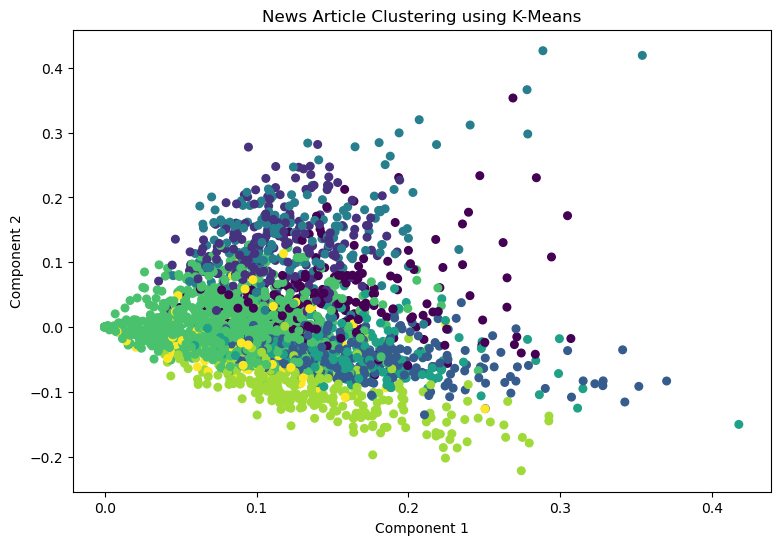

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_2D[:, 0],
    X_2D[:, 1],
    c=df["KMeans_Cluster"],
    s=30
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("News Article Clustering using K-Means")

plt.show()

In [24]:
sample_size = min(500, X.shape[0])

X_sample = X[:sample_size]

print("Sample Size:", sample_size)

Sample Size: 500


In [25]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_sample.toarray()
)

print("Hierarchical clustering completed!")

Hierarchical clustering completed!


In [26]:
hierarchical_score = silhouette_score(
    X_sample,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    hierarchical_score
)

Hierarchical Clustering Silhouette Score: -6.13250341424445e-05


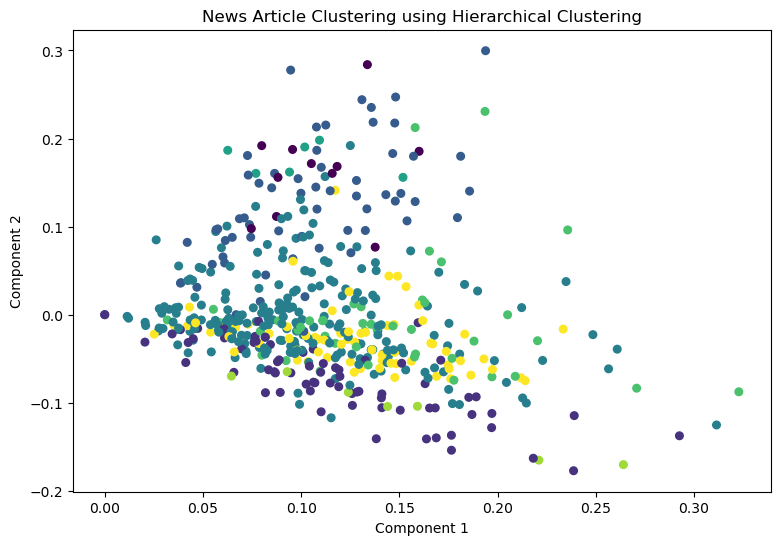

In [27]:
X_sample_2D = X_2D[:sample_size]

plt.figure(figsize=(9, 6))

plt.scatter(
    X_sample_2D[:, 0],
    X_sample_2D[:, 1],
    c=hierarchical_labels,
    s=30
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("News Article Clustering using Hierarchical Clustering")

plt.show()

In [28]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score
    ]
})

comparison

,Algorithm,Silhouette Score
0,K-Means,0.006781
1,Hierarchical Clustering,-0.000061
